# 1. Import das bibliotecas necessárias para o experimento


In [2]:
%pip install kagglehub opencv-python numpy pandas tqdm brisque ipywidgets numba -q

import kagglehub as kh
from pathlib import Path
import cv2
import numpy as np
from numba import njit
import matplotlib.pyplot as plt
from skimage.metrics import mean_squared_error
from skimage.metrics import peak_signal_noise_ratio
import skimage.transform
import PIL.Image
import pandas as pd
from brisque import BRISQUE

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.8/40.8 kB 3.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.5/155.5 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 109.2 MB/s eta 0:00:00


# 2. Funções:
### @njit
Em algumas funções é passado o argumento @njit antes delas, ele é da biblioteca numba e tem a função de transformar o código puro python na arquitetura do C/C++

### padding_reflection:
Aplica a reflexão de borda para que o kenel passe deslizando sobre a imagem com o objetivo de alterar o mínimo possível a imagem original

### Guass_mask:
Por meio dela e suas funções dependentes (sigma_formula, gauss_formula e create_weight_kernel), aplica o filtro gaussiano na imagem original, gerando outra imagem mais borrada da original.

### Equalização Global e Clahe:
Aplica a s equalizações Global e CLAHE na imagem gerada pelo resultado da expressão: *imagem_aprimorada = imagem_original * 1.5 - imagem_gauss * 0.5*

In [3]:

EULER = np.e
PI = np.pi

@njit
def padding_reflection(imagem, kernel, x, y):
    p = int((kernel-1)/2)
    imagem_aumentada = np.zeros((y + 2*p, x + 2*p))
    imagem_aumentada[p:y+p, p:x+p] = imagem

    #TOPO
    imagem_aumentada[:p, p:x+p] = imagem[p:0:-1, :]
    #BASE
    imagem_aumentada[y+p:, p:x+p] = imagem[-2:-p-2:-1, :]
    #ESQUERDA COM QUINAS
    imagem_aumentada[:, :p] = imagem_aumentada[:, 2*p:p:-1]
    #DIREITA COM QUINAS
    imagem_aumentada[:, p+x:] = imagem_aumentada[:, p+x-2:x-2:-1]

    return imagem_aumentada

def sigma_formula(kernel):
    sigma = 0.3 * ((kernel - 1)/2 - 1) + 0.8
    return sigma

def gauss_formula(y, x, sigma, center):
    return (1/(2*PI*(sigma**2)))*(EULER**-((((x - center)**2 + (y - center)**2)/(2*(sigma**2)))))

@njit
def gauss_mask(imagem, kernel, weight_matriz_kernel):
    y, x = imagem.shape
    matriz_com_borda =  padding_reflection(imagem, kernel, x, y)
    resultado = np.zeros_like(imagem, dtype=np.float64)

    for i in range(y):
        for j in range(x):
            corte = matriz_com_borda[i:i+kernel, j:j+kernel]
            resultado[i, j] = np.sum(corte * weight_matriz_kernel)

    return resultado

def create_weight_kernel(sigma, center):
    weight_matrix_kernel = np.fromfunction(gauss_formula, (5, 5), dtype=float, sigma=sigma, center=center)
    weight_matrix_kernel = weight_matrix_kernel/np.sum(weight_matrix_kernel)
    return weight_matrix_kernel

def aplicar_equalizacao_global(imagem_cinza):
    imagem_equalizada = cv2.equalizeHist(imagem_cinza)
    return imagem_equalizada

def aplicar_clahe(imagem_cinza, clip_limit=2.0, grid_size=(8, 8)):
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=grid_size)
    imagem_clahe = clahe.apply(imagem_cinza)
    return imagem_clahe

# 3. Criação dos dicionários com as transformações realizadas

Primeiro é feito o download do Brain tumor dataset por meio da biblioteca kagglehub, que deixa salvo em uma pasta .cache onde o programa roda e retorna o caminho até ela.

Depois, por meio de loops for, são criadas os seguintes dicionários de imagens:
- imagens_tumores: Imagens originais advindas do dataset
- imagens_tumores_gauss: Imagens com a aplicação do filtro gaussiano
- imagens_tumores_sharpened: Imagens aprimoradas por meio da equação citada no início
- imagens_tumores_clahe: Imagens equalizadas com algoritmo CLAHE

In [6]:
path = Path(kh.dataset_download("tombackert/brain-tumor-mri-data")).joinpath('brain-tumor-mri-dataset')

imagens_tumores = {}
nomes_imagens = []

#Cria um dicionário que armazena as classes e as matrizes de cada imagem
for pasta_tumor in path.iterdir():
    nome = pasta_tumor.name
    imagens_tumores[nome] = []

    for caminho_imagem in pasta_tumor.glob('*.*'):
        imagem = cv2.imread(str(caminho_imagem))
        nomes_imagens.append(str(caminho_imagem))

        imagem_cinza = (imagem[:, :, 0] * 0.114 + imagem[:, :, 1] * 0.587 + imagem[:, :, 2] * 0.299)
        tamanho = min(imagem_cinza.shape) // 2

        y_center = imagem.shape[0] // 2
        x_center = imagem.shape[1] // 2

        imagem = imagem_cinza[y_center - tamanho : y_center + tamanho, x_center - tamanho : x_center + tamanho]

        if imagem is not None:
            imagens_tumores[nome].append(imagem.astype(np.uint8))


imagens_tumores_gauss = {}

#Cria um dicionário com os filtros gaussianos de cada imagem
for nome in imagens_tumores:
    imagens_tumores_gauss[nome] = []
    for imagem in imagens_tumores[nome]:
        weight_kernel = create_weight_kernel(sigma_formula(5), np.uint8(5/2))
        imagem_gauss = gauss_mask(imagem, 5, weight_kernel).astype(np.uint8)
        imagens_tumores_gauss[nome].append(imagem_gauss)


imagens_tumores_sharpened = {}

#Cria um dicionário com a aplicação da equação de sharpness em cada uma das imagens
for nome in imagens_tumores:
    imagens_tumores_sharpened[nome] = []
    for i, imagem in enumerate(imagens_tumores[nome]):
        imagem_sharpened = (1.5 * imagem) - (0.5 * imagens_tumores_gauss[nome][i])
        imagens_tumores_sharpened[nome].append(imagem_sharpened.astype(np.uint8))


imagens_tumores_clahe = {}

#Cria um dicionário com a aplicação do algoritmo clahe nas imagens com o efeito de sharpness
for nome in imagens_tumores_sharpened:
    imagens_tumores_clahe[nome] = []
    for imagem in imagens_tumores_sharpened[nome]:
        imagem_clahe = aplicar_clahe(imagem)
        imagens_tumores_clahe[nome].append(imagem_clahe)

Using Colab cache for faster access to the 'brain-tumor-mri-data' dataset.


KeyboardInterrupt: 

# 4. Cálculo das Métricas nas imagens após o CLAHE:
Para cada imagem com clahe aplicado, é feito o cálculo das métricas MSE, PSNT e BRISQUE. Os valores obtidos são salvos em um arquivo csv.

Depois é feita uma análise da imagem gerdada com a aplicação da equação (descrita como Imagem Original no matplotlib) com as imagens geradas via equalização global e o método de CLAHE.

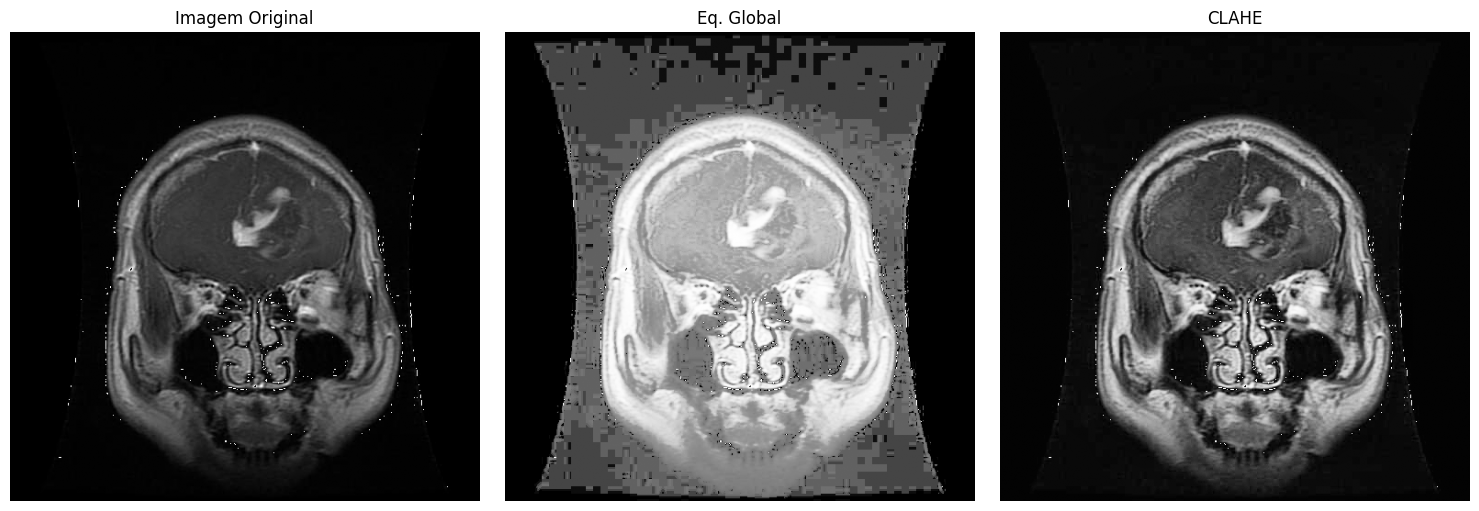

In [5]:
mse_list = []
psnr_list = []
brisque_list = []
brisque_obj = BRISQUE(url=False)

for nome in imagens_tumores:
    for i, imagem in enumerate(imagens_tumores[nome]):
        mse = mean_squared_error(imagem, imagens_tumores_clahe[nome][i])
        mse_list.append(mse)

        psnr = peak_signal_noise_ratio(imagem, imagens_tumores_clahe[nome][i], data_range=255)
        psnr_list.append(psnr)

        img_rgb = cv2.cvtColor(imagens_tumores_clahe[nome][i], cv2.COLOR_GRAY2RGB)

        ruido = np.random.randint(0, 3, size=img_rgb.shape, dtype=np.int16)

        img_brisque_ruido = np.clip(img_rgb.astype(np.int16) + ruido, 0, 255).astype(np.uint8)

        img_pil = PIL.Image.fromarray(img_brisque_ruido)

        try:
            brisque_valor = brisque_obj.score(img_pil)
        except Exception as e:
            print(f"Aviso: O cálculo BRISQUE falhou nesta imagem. Erro: {e}")
            brisque_valor = float('nan')

        brisque_list.append(brisque_valor)

df_metricas = pd.DataFrame({
    'Imagem':nomes_imagens,
    'mse': mse_list,
    'psnr': psnr_list,
    'brisque': brisque_list
})

df_metricas.to_csv('metricas.csv', sep=';', encoding='utf-8', index=False)



imagem_original = imagens_tumores_sharpened['glioma'][0]
img_global = aplicar_equalizacao_global(imagens_tumores_sharpened['glioma'][0])
img_clahe = imagens_tumores_clahe['glioma'][0]

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.title("Imagem Original")
plt.imshow(imagem_original, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("Eq. Global")
plt.imshow(img_global, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("CLAHE")
plt.imshow(img_clahe, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

In [7]:
#Ajeitando para que na coluna dos nomes não apareça todo o caminho da imagem
df_metricas['Imagem'] = df_metricas['Imagem'].apply(lambda caminho: Path(caminho).name)

df_metricas.to_csv('metricas.csv', sep=';', encoding='utf-8', index=False)

# 5. Download do novo dataset com as imagens CLAHE:
Cria-se uma pasta e suas subpastas para armazenar as imagens resultantes do método CLAHE e depois as imagens são escritas em cada subpasta de acordo com sua respectiva classe.

No final é feita a compactação da pasta para zip e o download do dataset começa instantaneamente.

In [ ]:
import os
import cv2
import shutil
from google.colab import files

pasta_principal = "dataset_clahe"
os.makedirs(pasta_principal, exist_ok=True)

cont = 0

for nome_classe, lista_imagens in imagens_tumores_clahe.items():

    caminho_classe = os.path.join(pasta_principal, nome_classe)
    os.makedirs(caminho_classe, exist_ok=True)

    for imagem_array in lista_imagens:
        nome_arquivo = f"{df_metricas['Imagem'][cont]}.png"
        caminho_arquivo = os.path.join(caminho_classe, nome_arquivo)

        cv2.imwrite(caminho_arquivo, imagem_array)

        cont += 1

shutil.make_archive(pasta_principal, 'zip', pasta_principal)

files.download(f"{pasta_principal}.zip")

Salvando imagens nas pastas...
Imagens salvas! Compactando a pasta...
Download iniciando...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>